# Treino LSTM com Dataset Pré-processado

Este notebook consome `frames_processados_v1.csv`, gerado no notebook 0. Ele cria tensores temporais com 15 frames e preserva `video_id` e `participant_id` em cada janela.

A avaliação usa Leave-One-Subject-Out. Em cada fold, um participante inteiro fica reservado para teste e o `StandardScaler` é ajustado exclusivamente nos dados de treino.

In [1]:
import json
import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import BatchNormalization, Bidirectional, Conv1D, Dense, Dropout, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

print("Bibliotecas importadas com sucesso")
print(f"TensorFlow: {tf.__version__}")

Bibliotecas importadas com sucesso
TensorFlow: 2.21.0


## 1. Carregar Frames Processados

Os dados são produzidos pelo notebook 0 e são a única fonte de entrada para este experimento. O participante retido no fold detalhado é configurado por `TEST_PARTICIPANT`; a avaliação completa reserva cada participante uma vez por meio de Leave-One-Subject-Out.

In [2]:
PROJECT_ROOT = Path.cwd()
PROCESSED_DATA_DIR = PROJECT_ROOT / "files_processados"
DATASET_VERSION = "v1"
WINDOW_SIZE = 15
STRIDE = 1
TARGET_FPS = 5.0

FRAMES_DATASET_PATH = PROCESSED_DATA_DIR / f"frames_processados_{DATASET_VERSION}.csv"
MANIFEST_PATH = PROCESSED_DATA_DIR / f"manifesto_dataset_{DATASET_VERSION}.json"
ML_MODELS_DIR = PROJECT_ROOT / "ml_models"
ML_MODELS_DIR.mkdir(exist_ok=True)

assert FRAMES_DATASET_PATH.is_file(), (
    f"Dataset não encontrado: {FRAMES_DATASET_PATH}. "
    "Execute primeiro o notebook 0-preprocessamento_dataset.ipynb."
)
with MANIFEST_PATH.open(encoding="utf-8") as manifest_file:
    manifest = json.load(manifest_file)

ANGLE_COLUMNS = [
    "right_cotovelo", "left_cotovelo", "right_ombro", "left_ombro",
    "right_joelho", "left_joelho", "right_quadril", "left_quadril",
]
angle_columns = ANGLE_COLUMNS
required_columns = {
    "video_id", "participant_id", "exercise_label", "frame", "timestamp_s",
    "is_valid_frame", *ANGLE_COLUMNS,
}
data = pd.read_csv(FRAMES_DATASET_PATH)
missing_columns = required_columns - set(data.columns)
if missing_columns:
    raise ValueError(f"Dataset incompatível; colunas ausentes: {sorted(missing_columns)}")

data = data.loc[data["is_valid_frame"]].copy()
if data[ANGLE_COLUMNS].isna().any().any():
    raise ValueError("Dataset contém ângulos ausentes em frames considerados válidos.")

print(f"Frames carregados: {len(data):,}")
print(f"Participantes: {sorted(data['participant_id'].unique().tolist())}")
print(f"Vídeos: {data['video_id'].nunique()} | Janela: {WINDOW_SIZE} | Stride: {STRIDE}")

Frames carregados: 15,042
Participantes: ['leticia', 'paulo', 'rafael', 'rodrigo']
Vídeos: 16 | Janela: 15 | Stride: 1


In [ ]:
summary_by_subject = (
    data.groupby(["participant_id", "exercise_label"], dropna=False)
    .agg(frames=("frame", "size"), videos=("video_id", "nunique"))
    .reset_index()
    .sort_values(["participant_id", "exercise_label"])
)
print("Resumo dos frames processados:")
display(summary_by_subject)

assert data.groupby("video_id")["participant_id"].nunique().eq(1).all()
assert data.groupby("video_id")["exercise_label"].nunique().eq(1).all()

Resumo dos frames processados:


,participant_id,exercise_label,frames,videos
0,leticia,agachamento,784,1
1,leticia,descanso,866,1
2,leticia,flexao,589,1
3,leticia,rosca_biceps,630,1
4,paulo,agachamento,499,1
5,paulo,descanso,607,1
6,paulo,flexao,509,1
7,paulo,rosca_biceps,691,1
8,rafael,agachamento,1587,1
9,rafael,descanso,1740,1


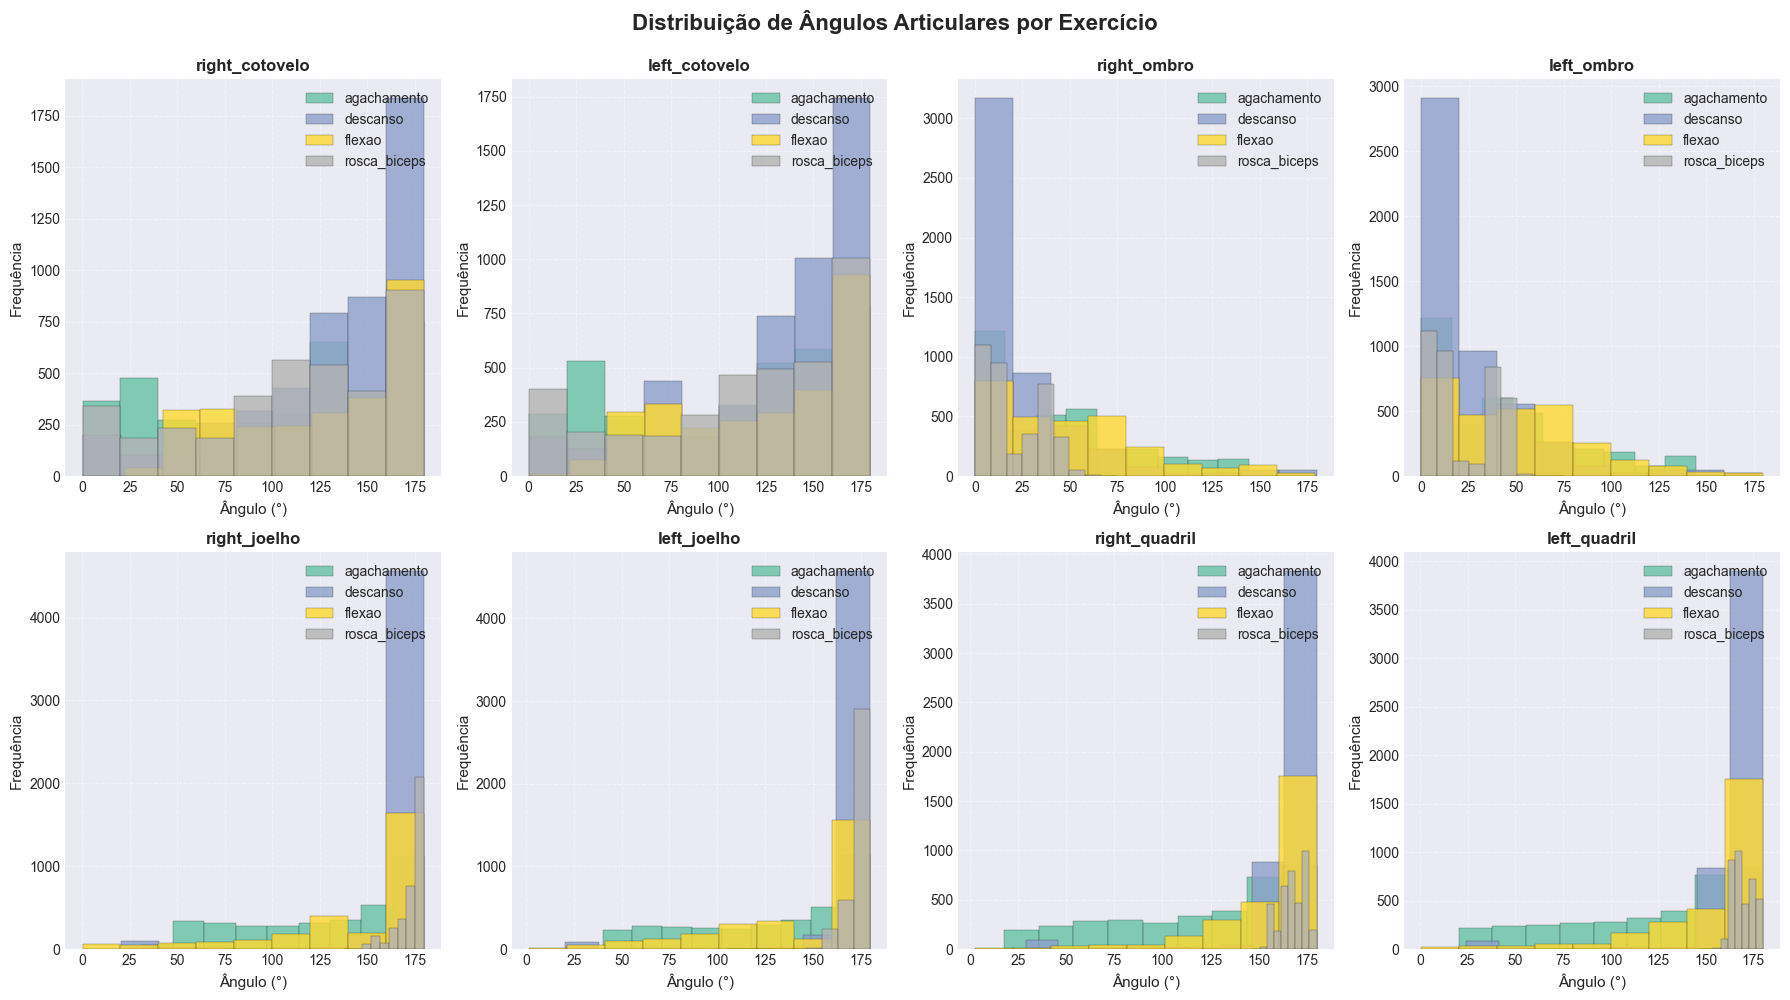

In [3]:
# Visualizar distribuições dos ângulos por exercício
# Isso ajuda a entender quais articulações são mais discriminativas entre as classes.
label_column = "exercise_label"
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

exercises = sorted(data[label_column].unique())
colors = plt.cm.Set2(np.linspace(0, 1, len(exercises)))
exercise_colors = dict(zip(exercises, colors))

for idx, column in enumerate(ANGLE_COLUMNS):
    for exercise in exercises:
        subset = data.loc[data[label_column].eq(exercise), column]
        axes[idx].hist(
            subset,
            alpha=0.8,
            label=exercise,
            bins=9,
            color=exercise_colors[exercise],
            edgecolor="black",
            linewidth=0.2,
        )
    axes[idx].set_title(column, fontsize=12, fontweight="bold")
    axes[idx].set_xlabel("Ângulo (°)", fontsize=11)
    axes[idx].set_ylabel("Frequência", fontsize=11)
    axes[idx].legend(fontsize=10, loc="upper right", framealpha=0.95)
    axes[idx].grid(alpha=0.4, linestyle="--")

plt.suptitle("Distribuição de Ângulos Articulares por Exercício", fontsize=16, fontweight="bold", y=0.995)
plt.tight_layout()
plt.show()

## 2. Criação de Tensores Temporais

A LSTM recebe tensores `(amostras, 15 frames, 22 features)`. Os frames vêm de `frames_processados_v1.csv` e as janelas são formadas internamente por `video_id`, portanto não cruzam vídeos.

Cada timestep contém 8 ângulos, 8 velocidades angulares, 4 assimetrias esquerda/direita e 2 atributos temporais. `participant_id` é preservado para a avaliação Leave-One-Subject-Out.

In [4]:
def create_temporal_windows_3d(df, window_size, stride, angle_columns):
    joint_pairs = [
        ("right_cotovelo", "left_cotovelo"),
        ("right_ombro", "left_ombro"),
        ("right_joelho", "left_joelho"),
        ("right_quadril", "left_quadril"),
    ]
    right_indices = [angle_columns.index(right) for right, _ in joint_pairs]
    left_indices = [angle_columns.index(left) for _, left in joint_pairs]

    sequences, labels, metadata = [], [], []
    for video_id, group in df.groupby("video_id", sort=False):
        group = group.sort_values("frame").reset_index(drop=True)
        video_start = float(group["timestamp_s"].min())
        video_duration = max(float(group["timestamp_s"].max()) - video_start, 1e-6)

        for start_index in range(0, len(group) - window_size + 1, stride):
            window = group.iloc[start_index : start_index + window_size]
            angles = window[angle_columns].to_numpy(dtype=np.float32)
            velocity = np.zeros_like(angles)
            velocity[1:] = angles[1:] - angles[:-1]
            asymmetry = angles[:, right_indices] - angles[:, left_indices]
            time_seconds = window["timestamp_s"].to_numpy(dtype=np.float32)
            frame_normalized = ((time_seconds - video_start) / video_duration).reshape(-1, 1)
            time_features = np.column_stack((frame_normalized, time_seconds.reshape(-1, 1)))
            sequences.append(np.concatenate([angles, velocity, asymmetry, time_features], axis=1))

            first_frame = window.iloc[0]
            metadata.append({
                "window_id": f"{video_id}__start_{int(first_frame['frame'])}__w{window_size}__s{stride}",
                "video_id": video_id,
                "participant_id": first_frame["participant_id"],
                "exercise_label": first_frame["exercise_label"],
                "window_start_frame": int(first_frame["frame"]),
                "window_end_frame": int(window.iloc[-1]["frame"]),
                "mean_visibility": float(window["mean_visibility"].mean()),
            })
            labels.append(first_frame["exercise_label"])

    X = np.asarray(sequences, dtype=np.float32)
    y = pd.Series(labels, name="exercise_label")
    meta = pd.DataFrame(metadata)
    if not len(X) or not meta["window_id"].is_unique:
        raise ValueError("Não foi possível gerar janelas LSTM válidas.")
    return X, y, meta

X, y, meta = create_temporal_windows_3d(data, WINDOW_SIZE, STRIDE, ANGLE_COLUMNS)
print(f"Janelas LSTM: {len(X):,}")
print(f"Shape: {X.shape} (janelas, frames, features)")
print("Features por timestep: 8 ângulos + 8 velocidades + 4 assimetrias + 2 temporais = 22")

Janelas LSTM: 14,818
Shape: (14818, 15, 22) (janelas, frames, features)
Features por timestep: 8 ângulos + 8 velocidades + 4 assimetrias + 2 temporais = 22


In [5]:
label_map = {"flexao": 0, "agachamento": 1, "descanso": 2, "rosca_biceps": 3}
reverse_label_map = {value: key for key, value in label_map.items()}
y_encoded = y.map(label_map)
if y_encoded.isna().any():
    raise ValueError(f"Classes não mapeadas: {sorted(y[y_encoded.isna()].unique().tolist())}")

TEST_PARTICIPANT = "rodrigo"
participants = sorted(meta["participant_id"].unique().tolist())
if TEST_PARTICIPANT not in participants:
    raise ValueError(f"TEST_PARTICIPANT deve ser um de: {participants}")

train_mask = meta["participant_id"].ne(TEST_PARTICIPANT).to_numpy()
test_mask = ~train_mask
X_train = X[train_mask]
y_train = y_encoded.loc[train_mask].reset_index(drop=True)
X_test = X[test_mask]
y_test = y_encoded.loc[test_mask].reset_index(drop=True)
meta_train = meta.loc[train_mask].reset_index(drop=True)
meta_test = meta.loc[test_mask].reset_index(drop=True)

print(f"Fold detalhado: teste em {TEST_PARTICIPANT}")
print(f"Treino: {len(X_train):,} janelas | participantes: {sorted(meta_train['participant_id'].unique())}")
print(f"Teste: {len(X_test):,} janelas | participante: {TEST_PARTICIPANT}")

Fold detalhado: teste em rodrigo
Treino: 11,286 janelas | participantes: ['leticia', 'paulo', 'rafael']
Teste: 3,532 janelas | participante: rodrigo


In [6]:
def undersample_training_sequences(X_split, y_split, random_state=42):
    rng = np.random.RandomState(random_state)
    target_count = y_split.value_counts().min()
    selected_indices = np.concatenate([
        rng.choice(y_split.index[y_split.eq(label)], size=target_count, replace=False)
        for label in sorted(y_split.unique())
    ])
    rng.shuffle(selected_indices)
    return X_split[selected_indices], y_split.loc[selected_indices].reset_index(drop=True)

X_train, y_train = undersample_training_sequences(X_train, y_train)
print("Distribuição do treino balanceado:")
display(y_train.map(reverse_label_map).value_counts().rename("windows").to_frame())
print("Distribuição original do teste:")
display(y_test.map(reverse_label_map).value_counts().rename("windows").to_frame())

Distribuição do treino balanceado:


,windows
exercise_label,
flexao,2249
agachamento,2249
descanso,2249
rosca_biceps,2249


Distribuição original do teste:


,windows
exercise_label,
descanso,1680
agachamento,698
rosca_biceps,657
flexao,497


## 3. Normalização das Features

O `StandardScaler` é ajustado somente nos frames das janelas de treino. Como o tensor tem 22 features por timestep, ele é achatado para duas dimensões durante a normalização e restaurado para `(amostras, 15, 22)` antes da LSTM.

O conjunto de teste apenas recebe `transform`; ele não participa do cálculo de média ou desvio padrão.

In [7]:
# ── Normalização sem vazamento: fit apenas no treino ─────────────────────────
# X shape: (n_amostras, window_size=15, n_angles=8)
# Estratégia: reshape para 2D → fit/transform → reshape de volta para 3D

n_train, window_size, n_features = X_train.shape
n_test = X_test.shape[0]
n_classes = len(label_map)

scaler = StandardScaler()

# Reshape: (n_amostras, 15, 8) → (n_amostras * 15, 8)
X_train_2d = X_train.reshape(-1, n_features)
X_test_2d  = X_test.reshape(-1, n_features)

# Scaler FITADO SOMENTE NO TREINO — o teste apenas é transformado
X_train_scaled_2d = scaler.fit_transform(X_train_2d)
X_test_scaled_2d  = scaler.transform(X_test_2d)   # apenas transform!

# Restaurar shape 3D para a LSTM
X_train_scaled = X_train_scaled_2d.reshape(n_train, window_size, n_features)
X_test_scaled  = X_test_scaled_2d.reshape(n_test,  window_size, n_features)

# Converter labels para one-hot encoding (necessário para softmax + categorical_crossentropy)
y_train_cat = to_categorical(y_train, num_classes=n_classes)
y_test_cat  = to_categorical(y_test,  num_classes=n_classes)

print("✓ Dados normalizados (scaler fitado apenas no treino):")
print(f"  X_train_scaled: {X_train_scaled.shape}  → input da LSTM")
print(f"  X_test_scaled:  {X_test_scaled.shape}")
print(f"\n✓ Labels em one-hot ({n_classes} classes):")
print(f"  y_train_cat: {y_train_cat.shape}")
print(f"  y_test_cat:  {y_test_cat.shape}")
print(f"\n  Mapeamento: {label_map}")

✓ Dados normalizados (scaler fitado apenas no treino):
  X_train_scaled: (8996, 15, 22)  → input da LSTM
  X_test_scaled:  (3532, 15, 22)

✓ Labels em one-hot (4 classes):
  y_train_cat: (8996, 4)
  y_test_cat:  (3532, 4)

  Mapeamento: {'flexao': 0, 'agachamento': 1, 'descanso': 2, 'rosca_biceps': 3}


## 3b. Cross-Validação por Vídeo — Leave-One-Subject-Out

Para avaliar a **generalização entre sujeitos**, aplicamos **Leave-One-Subject-Out Cross-Validation** com **todos os dados disponíveis** (Rafael, Paulo, Letícia e Rodrigo).

### Protocolo — 4 folds:
| Fold | Treino | Teste |
|---|---|---|
| 1 | Paulo + Letícia + Rodrigo | Rafael |
| 2 | Rafael + Letícia + Rodrigo | Paulo |
| 3 | Rafael + Paulo + Rodrigo | Letícia |
| 4 | Rafael + Paulo + Letícia | Rodrigo |

Cada fold **treina um modelo do zero** com a mesma arquitetura (Conv1D + Bidirectional LSTM).  
O split da seção 4 (treino = Rafael/Paulo/Letícia, teste = Rodrigo) é apenas uma das 4 partições avaliadas aqui.

Os resultados desta etapa **não influenciam** os pesos do modelo final treinado na seção 4.


🔄 Cross-Validação Leave-One-Subject-Out  (4 sujeitos = 4 folds)
   Sujeitos: ['leticia', 'paulo', 'rafael', 'rodrigo']

  Fold 1/4  (held-out: leticia )  n_treino=8684  n_teste=2300  →  acc=0.4326  f1=0.4234
  Fold 2/4  (held-out: paulo   )  n_treino=9004  n_teste=1455  →  acc=1.0000  f1=1.0000
  Fold 3/4  (held-out: rafael  )  n_treino=6268  n_teste=4716  →  acc=0.4998  f1=0.4732
  Fold 4/4  (held-out: rodrigo )  n_treino=8996  n_teste=1988  →  acc=0.6836  f1=0.6792

  RESUMO — Cross-Validação Leave-One-Subject-Out (todos os sujeitos)
 fold sujeito_teste  n_treino  n_teste  accuracy  f1_weighted
    1       leticia      8684     2300  0.432609     0.423422
    2         paulo      9004     1455  1.000000     1.000000
    3        rafael      6268     4716  0.499788     0.473159
    4       rodrigo      8996     1988  0.683602     0.679185

  Acurácia  média : 0.6540  ±  0.2539
  F1 ponderado    : 0.6439  ±  0.2619

💡 Modelo final (seção 4) usa treino=Rafael/Paulo/Letícia, teste=Rodrig

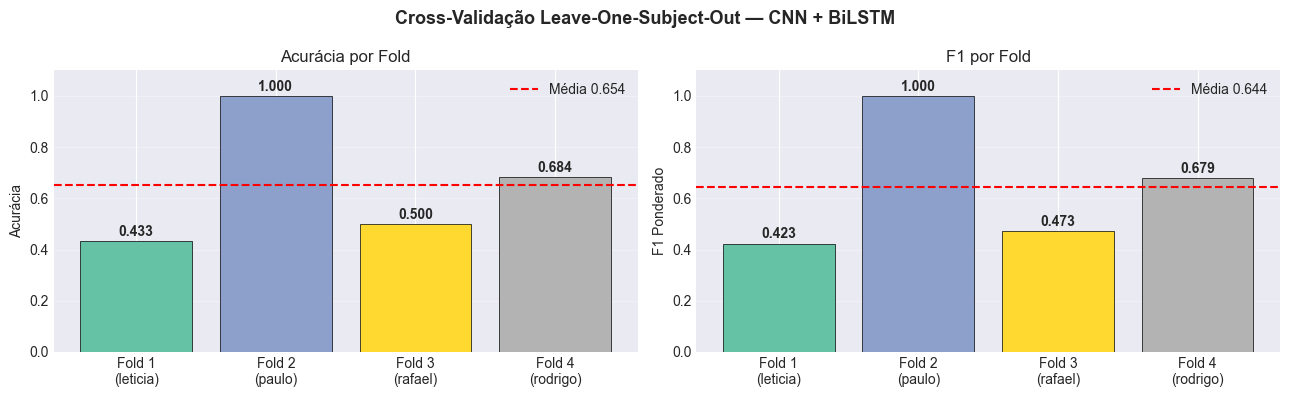

In [ ]:
def build_fold_model(input_shape, n_classes):
    model = Sequential([
        Conv1D(64, kernel_size=3, activation="relu", padding="same", input_shape=input_shape),
        Dropout(0.2),
        Bidirectional(LSTM(64, activation="tanh", return_sequences=True)),
        Dropout(0.3),
        LSTM(32, activation="tanh"),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dropout(0.2),
        Dense(n_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

logo = LeaveOneGroupOut()
subject_groups = meta["participant_id"].to_numpy()
cv_results = []

for fold_index, (train_index, test_index) in enumerate(logo.split(X, y_encoded, subject_groups), start=1):
    held_out_participant = subject_groups[test_index[0]]
    X_fold_train = X[train_index]
    y_fold_train = y_encoded.iloc[train_index].reset_index(drop=True)
    X_fold_test = X[test_index]
    y_fold_test = y_encoded.iloc[test_index].reset_index(drop=True)
    X_fold_train, y_fold_train = undersample_training_sequences(X_fold_train, y_fold_train)

    n_fold_train, fold_window_size, fold_features = X_fold_train.shape
    n_fold_test = X_fold_test.shape[0]
    fold_scaler = StandardScaler()
    X_fold_train_scaled = fold_scaler.fit_transform(X_fold_train.reshape(-1, fold_features)).reshape(
        n_fold_train, fold_window_size, fold_features
    )
    X_fold_test_scaled = fold_scaler.transform(X_fold_test.reshape(-1, fold_features)).reshape(
        n_fold_test, fold_window_size, fold_features
    )

    keras.backend.clear_session()
    fold_model = build_fold_model((fold_window_size, fold_features), len(label_map))
    fold_callbacks = [
        EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-5, verbose=0),
    ]
    fold_model.fit(
        X_fold_train_scaled,
        to_categorical(y_fold_train, num_classes=len(label_map)),
        validation_split=0.15,
        epochs=80,
        batch_size=32,
        callbacks=fold_callbacks,
        verbose=0,
    )
    y_fold_prediction = fold_model.predict(X_fold_test_scaled, verbose=0).argmax(axis=1)
    cv_results.append({
        "fold": fold_index,
        "test_participant": held_out_participant,
        "train_windows": n_fold_train,
        "test_windows": n_fold_test,
        "accuracy": accuracy_score(y_fold_test, y_fold_prediction),
        "f1_weighted": f1_score(y_fold_test, y_fold_prediction, average="weighted"),
        "f1_macro": f1_score(y_fold_test, y_fold_prediction, average="macro"),
    })

    del fold_model

keras.backend.clear_session()
cv_df = pd.DataFrame(cv_results).sort_values("test_participant").reset_index(drop=True)
display(cv_df)
print(
    f"Média LOSO: accuracy={cv_df['accuracy'].mean():.4f} ± {cv_df['accuracy'].std(ddof=0):.4f} | "
    f"F1 macro={cv_df['f1_macro'].mean():.4f} ± {cv_df['f1_macro'].std(ddof=0):.4f}"
)

## 4. Arquitetura da Rede LSTM

### Design:
- **LSTM(64, return_sequences=True)**: primeira camada — processa a sequência de 15 frames e passa os estados ocultos para a próxima camada LSTM
- **LSTM(32, return_sequences=False)**: segunda camada — consolida toda a sequência em um vetor de representação
- **BatchNormalization**: estabiliza o gradiente e acelera a convergência
- **Dropout**: regularização para reduzir overfitting
- **Dense(4, softmax)**: saída com probabilidades para as 4 classes

### Por que LSTM e não apenas Dense?
A LSTM captura **dependências temporais** entre frames: ela aprende que a *sequência de movimentos* (não apenas ângulos isolados) é o que define cada exercício.  
O Random Forest trata os 15 frames como 120 features independentes — a LSTM mantém a ordem temporal explicitamente com memória de curto e longo prazo.

In [8]:
# Construir modelo CNN + Bidirectional LSTM
# Input shape: (window_size=15, n_features=22)
#
# Arquitetura melhorada:
#   1. Conv1D(64, kernel=3): extrai padrões locais em janelas de 3 frames consecutivos
#      → detecta "micro-movimentos" antes de analisar a sequência completa
#   2. Bidirectional LSTM(64): processa a sequência em AMBAS as direções
#      → contexto de frames futuros ajuda a classificar o frame atual
#   3. LSTM(32): consolida a sequência bidirecional em um vetor
#   4. Dense(32) + Dropout: discriminação entre as 4 classes
model = Sequential([
    # Extração de padrões locais: janela de 3 frames → detecta micro-dinâmicas
    Conv1D(64, kernel_size=3, activation='relu', padding='same',
           input_shape=(window_size, n_features)),
    Dropout(0.2),

    # LSTM bidirecional: lê a sequência do início→fim e do fim→início
    # → agachamento tem simetria temporal diferente de flexão
    Bidirectional(LSTM(64, activation='tanh', return_sequences=True)),
    Dropout(0.3),

    # 2ª camada LSTM — consolida a representação bidirecional
    LSTM(32, activation='tanh', return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),

    # Camadas densas para discriminação entre as classes
    Dense(32, activation='relu'),
    Dropout(0.2),

    # Saída: probabilidade para cada uma das 4 classes
    Dense(n_classes, activation='softmax'),
])

# Compilar com Adam e categorical_crossentropy (multiclasse)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("🏗️  Arquitetura — CNN + Bidirectional LSTM:\n")
model.summary()
print(f"\n✓ Modelo compilado com Adam (lr=1e-3)")
print(f"  Input:  (batch, {window_size} frames, {n_features} features/frame)")
print(f"    └── 8 ângulos + 8 velocidades + 4 assimetrias + 2 temporais")
print(f"  Output: (batch, {n_classes} classes)  — {list(label_map.keys())}")


🏗️  Arquitetura — CNN + Bidirectional LSTM:



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 15, 64)         │         4,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 15, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,260 (360.39 KB)

 Trainable params: 92,196 (360.14 KB)

 Non-trainable params: 64 (256.00 B)


✓ Modelo compilado com Adam (lr=1e-3)
  Input:  (batch, 15 frames, 22 features/frame)
    └── 8 ângulos + 8 velocidades + 4 assimetrias + 2 temporais
  Output: (batch, 4 classes)  — ['flexao', 'agachamento', 'descanso', 'rosca_biceps']


In [9]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=7,
        min_lr=1e-5,
        verbose=1,
    ),
]

# A validação para early stopping vem exclusivamente de uma fração do treino.
# X_test_scaled permanece isolado para a avaliação final do participante retido.
print("Iniciando treinamento...\n")
history = model.fit(
    X_train_scaled,
    y_train_cat,
    validation_split=0.15,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1,
)

print("\nTreinamento concluído!")
print(f"  Épocas treinadas: {len(history.history['loss'])}")
print(f"  Melhor val_loss: {min(history.history['val_loss']):.4f}")
print(f"  Melhor val_accuracy: {max(history.history['val_accuracy']):.4f}")

Iniciando treinamento...

Epoch 1/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8289 - loss: 0.4625 - val_accuracy: 0.9274 - val_loss: 0.1881 - learning_rate: 0.0010
Epoch 2/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9479 - loss: 0.1468 - val_accuracy: 0.9593 - val_loss: 0.0899 - learning_rate: 0.0010
Epoch 3/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9559 - loss: 0.1259 - val_accuracy: 0.9644 - val_loss: 0.0917 - learning_rate: 0.0010
Epoch 4/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9638 - loss: 0.0992 - val_accuracy: 0.9681 - val_loss: 0.0701 - learning_rate: 0.0010
Epoch 5/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9613 - loss: 0.1035 - val_accuracy: 0.9756 - val_loss: 0.0588 - learning_rate: 0.0010
Epoch 6/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9744 - loss: 0.0687 - val_accuracy: 0.9726 - val_loss: 0.0649 - learning_rate: 0.0010
Epoch 7/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - 

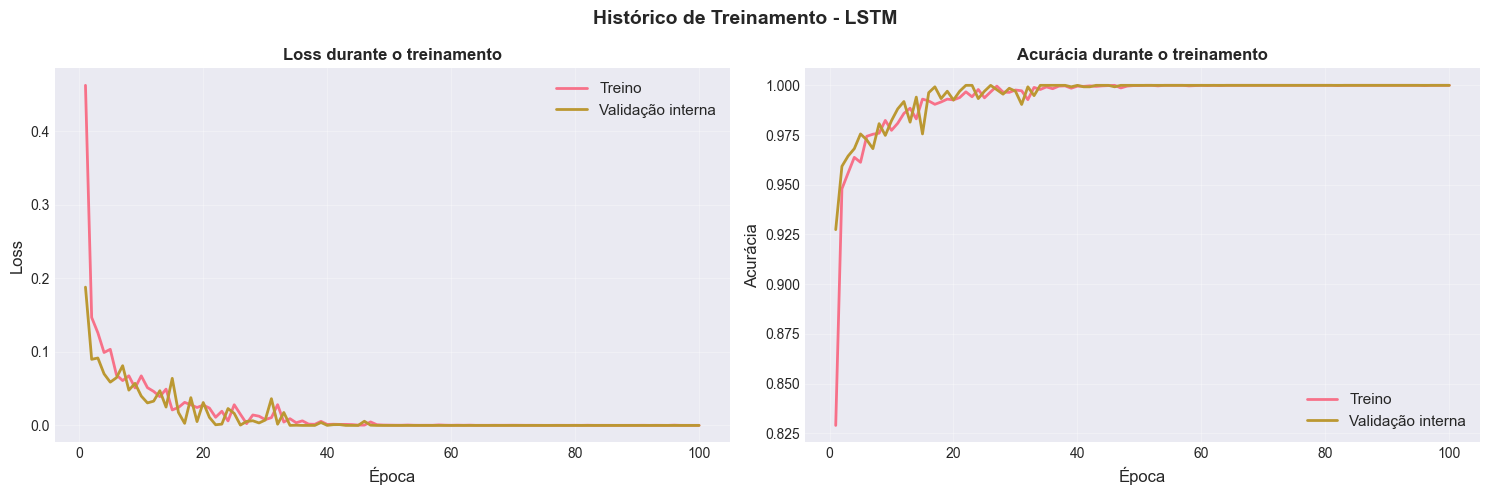


Resumo da validação interna:
  Treino - loss: 0.0001 | acc: 1.0000
  Validação interna - loss: 0.0000 | acc: 1.0000
  Teste LOSO (rodrigo): consulte a seção de avaliação.


In [12]:
# Visualizar histórico de treinamento.
# A validação interna é usada apenas durante o treino; o teste LOSO é avaliado na seção seguinte.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Histórico de Treinamento - LSTM", fontsize=14, fontweight="bold")

epochs = range(1, len(history.history["loss"]) + 1)

axes[0].plot(epochs, history.history["loss"], label="Treino", linewidth=2)
axes[0].plot(epochs, history.history["val_loss"], label="Validação interna", linewidth=2)
axes[0].set_xlabel("Época", fontsize=12)
axes[0].set_ylabel("Loss", fontsize=12)
axes[0].set_title("Loss durante o treinamento", fontweight="bold")
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history.history["accuracy"], label="Treino", linewidth=2)
axes[1].plot(epochs, history.history["val_accuracy"], label="Validação interna", linewidth=2)
axes[1].set_xlabel("Época", fontsize=12)
axes[1].set_ylabel("Acurácia", fontsize=12)
axes[1].set_title("Acurácia durante o treinamento", fontweight="bold")
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nResumo da validação interna:")
print(f"  Treino - loss: {history.history['loss'][-1]:.4f} | acc: {history.history['accuracy'][-1]:.4f}")
print(f"  Validação interna - loss: {history.history['val_loss'][-1]:.4f} | acc: {history.history['val_accuracy'][-1]:.4f}")
print(f"  Teste LOSO ({TEST_PARTICIPANT}): consulte a seção de avaliação.")

## 5. Avaliar Desempenho do Modelo

Avaliação no conjunto de **teste** (Rodrigo — sujeito completamente novo):
- **Matriz de confusão**: mostra onde o modelo erra e acerta
- **Acurácia por classe**: identifica classes difíceis de classificar
- **Classification report**: precision, recall e F1 por exercício

Também avaliamos apenas os **exercícios ativos** (excluindo descanso) para medir a capacidade de discriminação entre movimentos sem a classe "fácil".

📊 Resultados no conjunto de TESTE (Rodrigo — nunca visto no treino):
  Accuracy:      0.6543  (treino: 1.0000)
  F1 (weighted): 0.6622  (treino: 1.0000)

              precision    recall  f1-score   support

      flexao       0.94      0.54      0.68       497
 agachamento       0.77      0.94      0.84       698
    descanso       0.74      0.65      0.69      1680
rosca_biceps       0.32      0.44      0.37       657

    accuracy                           0.65      3532
   macro avg       0.69      0.64      0.65      3532
weighted avg       0.70      0.65      0.66      3532



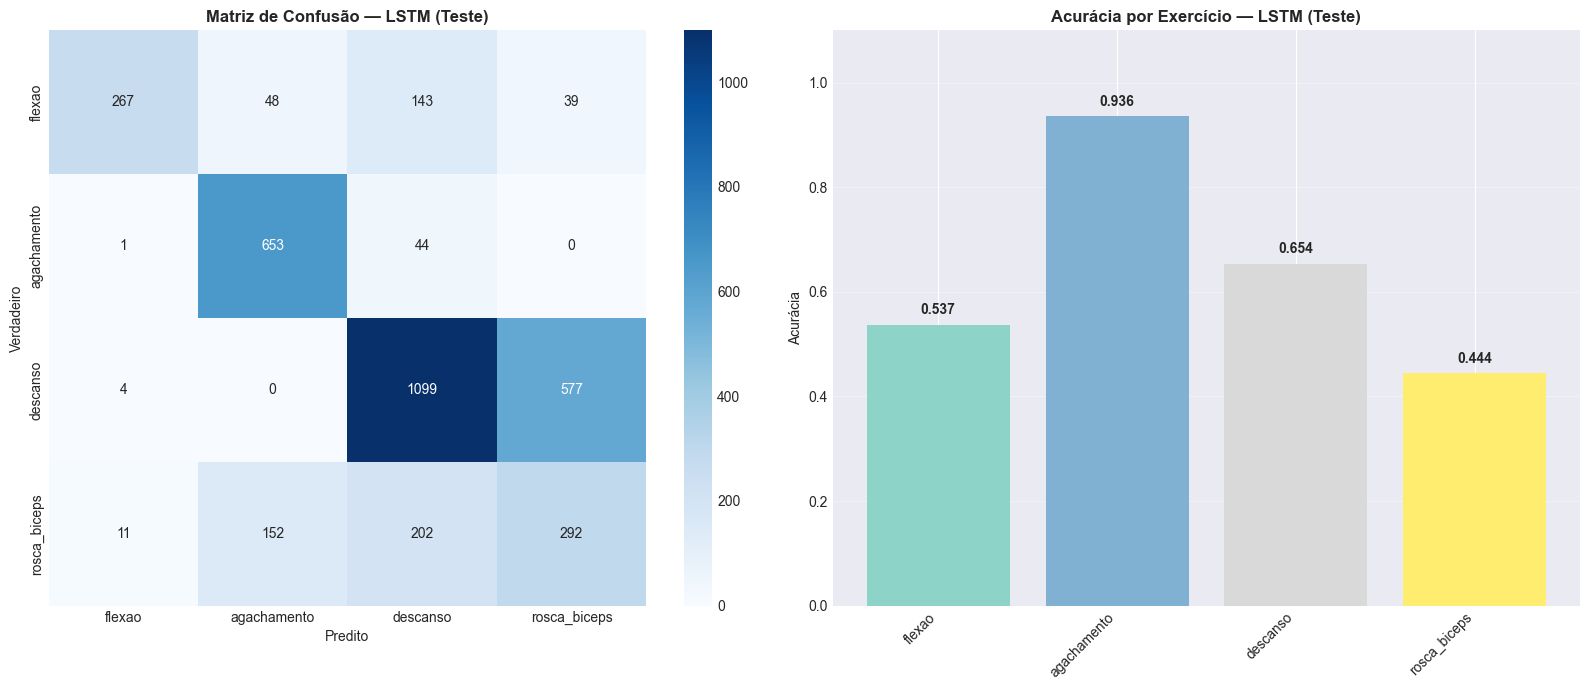

In [10]:
# Predições — o scaler já foi aplicado em X_train_scaled / X_test_scaled
y_train_pred_enc = model.predict(X_train_scaled, verbose=0).argmax(axis=1)
y_test_pred_enc  = model.predict(X_test_scaled,  verbose=0).argmax(axis=1)

# Métricas gerais
train_accuracy = accuracy_score(y_train, y_train_pred_enc)
test_accuracy  = accuracy_score(y_test,  y_test_pred_enc)
train_f1 = f1_score(y_train, y_train_pred_enc, average='weighted')
test_f1  = f1_score(y_test,  y_test_pred_enc,  average='weighted')

target_names = [reverse_label_map[i] for i in sorted(label_map.values())]
cm = confusion_matrix(y_test, y_test_pred_enc, labels=sorted(label_map.values()))

print(f"📊 Resultados no conjunto de TESTE (Rodrigo — nunca visto no treino):")
print(f"  Accuracy:      {test_accuracy:.4f}  (treino: {train_accuracy:.4f})")
print(f"  F1 (weighted): {test_f1:.4f}  (treino: {train_f1:.4f})")
print(f"\n{classification_report(y_test, y_test_pred_enc, target_names=target_names, zero_division=0)}")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Matriz de confusão
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=True,
            xticklabels=target_names, yticklabels=target_names)
axes[0].set_title('Matriz de Confusão — LSTM (Teste)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Verdadeiro')
axes[0].set_xlabel('Predito')

# Acurácia por classe
per_class_totals = cm.sum(axis=1)
with np.errstate(divide='ignore', invalid='ignore'):
    per_class_accuracy = np.where(per_class_totals > 0, cm.diagonal() / per_class_totals, np.nan)
colors_bar = plt.cm.Set3(np.linspace(0, 1, len(target_names)))
axes[1].bar(target_names, [v if not np.isnan(v) else 0 for v in per_class_accuracy], color=colors_bar)
axes[1].set_ylabel('Acurácia')
axes[1].set_title('Acurácia por Exercício — LSTM (Teste)', fontsize=12, fontweight='bold')
axes[1].set_ylim([0, 1.1])
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(per_class_accuracy):
    label_txt = f'{v:.3f}' if not np.isnan(v) else 'n/a'
    axes[1].text(i, (v if not np.isnan(v) else 0) + 0.02, label_txt, ha='center', fontweight='bold')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

  ACURÁCIA — APENAS EXERCÍCIOS ATIVOS (flexão, agach., rosca)

  Conjunto               Acurácia
  --------------------------------
  Treino                   1.0000
  Teste                    0.6544

  CLASSIFICATION REPORT — TESTE (active)
              precision    recall  f1-score   support

      flexao       0.96      0.54      0.69       497
 agachamento       0.77      0.94      0.84       698
rosca_biceps       0.88      0.44      0.59       657

   micro avg       0.83      0.65      0.73      1852
   macro avg       0.87      0.64      0.71      1852
weighted avg       0.86      0.65      0.71      1852



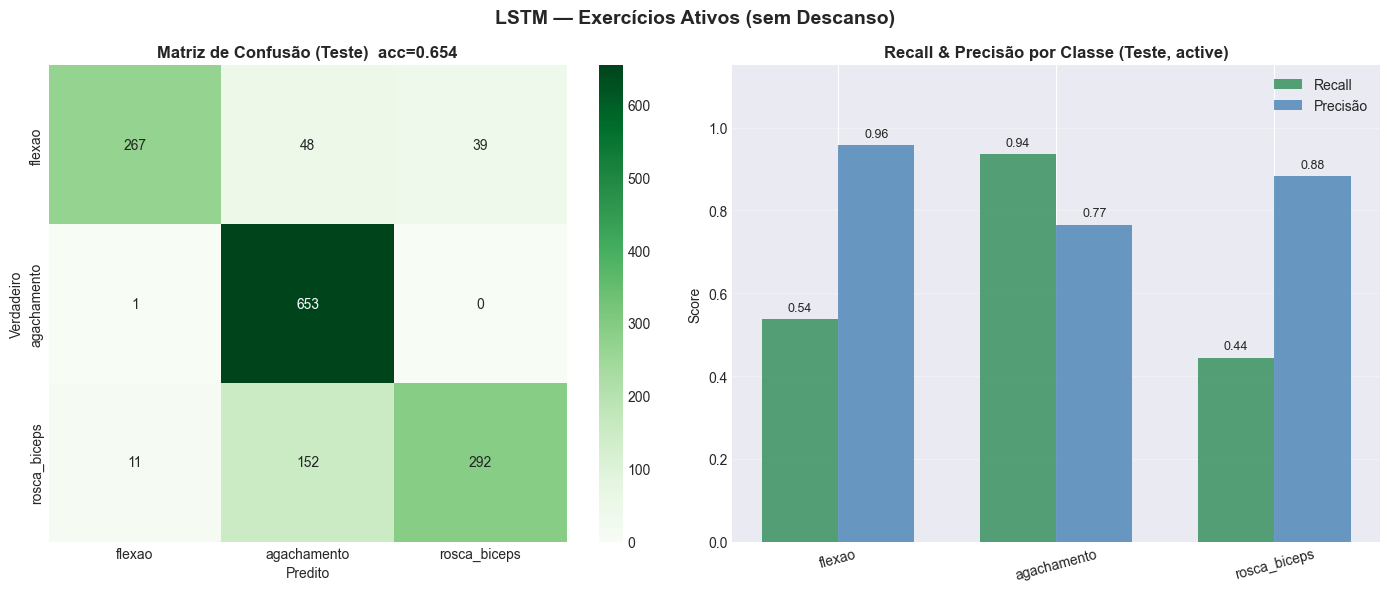

In [13]:
# ── Filtrar apenas exercícios ativos (excluindo descanso) ────────────────────
# O descanso costuma ser trivialmente separável (postura parada), então avaliamos
# a capacidade do modelo de discriminar entre os exercícios de movimento.
active_labels = {k: v for k, v in label_map.items() if k != 'descanso'}
active_label_values = list(active_labels.values())

active_mask_test  = y_test.isin(active_label_values)
active_mask_train = y_train.isin(active_label_values)

y_test_active  = y_test[active_mask_test].reset_index(drop=True)
y_train_active = y_train[active_mask_train].reset_index(drop=True)
y_test_pred_act  = y_test_pred_enc[active_mask_test.values]
y_train_pred_act = y_train_pred_enc[active_mask_train.values]

active_names = [reverse_label_map[i] for i in sorted(active_label_values)]

acc_train_active = accuracy_score(y_train_active, y_train_pred_act)
acc_test_active  = accuracy_score(y_test_active,  y_test_pred_act)

print("=" * 65)
print("  ACURÁCIA — APENAS EXERCÍCIOS ATIVOS (flexão, agach., rosca)")
print("=" * 65)
print(f"\n  {'Conjunto':<12} {'Acurácia':>18}")
print(f"  {'-'*32}")
print(f"  {'Treino':<12} {acc_train_active:>18.4f}")
print(f"  {'Teste':<12} {acc_test_active:>18.4f}")

print(f"\n{'='*65}")
print("  CLASSIFICATION REPORT — TESTE (active)")
print(f"{'='*65}")
print(classification_report(y_test_active, y_test_pred_act,
                             labels=sorted(active_label_values),
                             target_names=active_names, zero_division=0))

# ── Gráfico ──────────────────────────────────────────────────────────────────
cm_active = confusion_matrix(y_test_active, y_test_pred_act,
                             labels=sorted(active_label_values))
report_active = classification_report(y_test_active, y_test_pred_act,
                                      labels=sorted(active_label_values),
                                      target_names=active_names,
                                      output_dict=True, zero_division=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('LSTM — Exercícios Ativos (sem Descanso)', fontsize=14, fontweight='bold')

sns.heatmap(cm_active, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=active_names, yticklabels=active_names)
axes[0].set_title(f'Matriz de Confusão (Teste)  acc={acc_test_active:.3f}', fontweight='bold')
axes[0].set_ylabel('Verdadeiro'); axes[0].set_xlabel('Predito')

rec  = [report_active[c]['recall']    for c in active_names]
prec = [report_active[c]['precision'] for c in active_names]
x = np.arange(len(active_names))
w = 0.35
axes[1].bar(x - w/2, rec,  w, label='Recall',   color='seagreen',  alpha=0.8)
axes[1].bar(x + w/2, prec, w, label='Precisão', color='steelblue', alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(active_names, rotation=15)
axes[1].set_ylim([0, 1.15]); axes[1].set_ylabel('Score')
axes[1].set_title('Recall & Precisão por Classe (Teste, active)', fontweight='bold')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
for i, (r, p) in enumerate(zip(rec, prec)):
    axes[1].text(i - w/2, r + 0.02, f'{r:.2f}', ha='center', fontsize=9)
    axes[1].text(i + w/2, p + 0.02, f'{p:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [14]:
# ── Salvar artefatos do modelo LSTM ──────────────────────────────────────────
# Salvamos 3 artefatos necessários para inferência em novos vídeos:
#   1. Modelo LSTM completo (arquitetura + pesos)
#   2. Scaler (para normalizar novas janelas com as mesmas estatísticas do treino)
#   3. Label map (para converter predição numérica de volta ao nome do exercício)

print("💾 Salvando artefatos...\n")

# Modelo Keras (.keras é o formato recomendado pós-TF 2.12)
lstm_model_path = ML_MODELS_DIR / "lstm_4exercises_model.keras"
model.save(lstm_model_path)
model_size = lstm_model_path.stat().st_size / 1024
print(f"  ✓ Modelo LSTM:   {lstm_model_path} ({model_size:.1f} KB)")

# Scaler — necessário para normalizar novas janelas na inferência
scaler_path = ML_MODELS_DIR / "lstm_4exercises_scaler.pkl"
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
scaler_size = scaler_path.stat().st_size / 1024
print(f"  ✓ Scaler:        {scaler_path} ({scaler_size:.1f} KB)")

# Label map — necessário para reverter predição numérica para nome do exercício
label_map_path = ML_MODELS_DIR / "lstm_4exercises_label_map.pkl"
with open(label_map_path, 'wb') as f:
    pickle.dump(label_map, f)
print(f"  ✓ Label Map:     {label_map_path}")

print(f"\n📐 Configurações de inferência:")
print(f"  Window size:  {window_size} frames")
print(f"  N. ângulos:   {n_features}")
print(f"  N. classes:   {n_classes}")
print(f"\n💡 Passos para inferência em novos dados:")
print(f"  1. Extrair janela de {window_size} frames → shape ({window_size}, {n_features})")
print(f"  2. Reshape para (1, {window_size * n_features}) → scaler.transform → reshape (1, {window_size}, {n_features})")
print(f"  3. pred = model.predict(window_scaled).argmax()  →  reverse_label_map[pred]")

💾 Salvando artefatos...

  ✓ Modelo LSTM:   c:\Users\Rafael Luckner\Documents\repos\uniso\RACE - TCC\ml_models\lstm_4exercises_model.keras (1146.7 KB)
  ✓ Scaler:        c:\Users\Rafael Luckner\Documents\repos\uniso\RACE - TCC\ml_models\lstm_4exercises_scaler.pkl (0.9 KB)
  ✓ Label Map:     c:\Users\Rafael Luckner\Documents\repos\uniso\RACE - TCC\ml_models\lstm_4exercises_label_map.pkl

📐 Configurações de inferência:
  Window size:  15 frames
  N. ângulos:   22
  N. classes:   4

💡 Passos para inferência em novos dados:
  1. Extrair janela de 15 frames → shape (15, 22)
  2. Reshape para (1, 330) → scaler.transform → reshape (1, 15, 22)
  3. pred = model.predict(window_scaled).argmax()  →  reverse_label_map[pred]


## 9. 💡 Sugestões de Melhorias

### Arquitetura
| Sugestão | Por que pode ajudar |
|---|---|
| **Bidirectional LSTM** | Processa a sequência em ambas as direções — útil pois frames futuros também contêm contexto para classificar o exercício atual (`Bidirectional(LSTM(64))`) |
| **1D CNN + LSTM** | CNN extrai padrões locais de ativação (3–5 frames), LSTM captura dinâmica de longo prazo — `Conv1D → MaxPooling1D → LSTM` |
| **Self-Attention / Transformer Encoder** | Aprende quais frames da janela são mais relevantes sem depender de recorrência — geralmente supera LSTM em séries temporais |
| **GRU** | Equivalente à LSTM com menos parâmetros — treina mais rápido com performance comparável |

### Features
| Sugestão | Por que pode ajudar |
|---|---|
| **Combinar ângulos + velocidade angular (Δangles)** | Ângulos descrevem postura; deltas descrevem dinâmica — juntos formam representação mais completa (`n_features = 8 + 8 + 2 = 18`) |
| **Assimetria L/R** | `right_angle − left_angle` por articulação captura desequilíbrios posturais específicos de cada exercício |
| **Energia do movimento** | `sqrt(Σ Δangle²)` por frame — resume a intensidade do movimento naquele instante |

### Dados e Treinamento
| Sugestão | Por que pode ajudar |
|---|---|
| **Aumentar `window_size` para 30** | Captura ciclos completos de movimentos mais lentos (agachamento ~6 s a 5 fps) |
| **Data augmentation** | Ruído gaussiano nos ângulos (`σ ≈ 1°`) ou time-stretch simulado aumenta robustez a variações individuais |
| **Label smoothing** | `CategoricalCrossentropy(label_smoothing=0.1)` — reduz overconfidence e melhora generalização |
| **LSTM Stateful** | Processa vídeos inteiros frame a frame mantendo estado oculto — elimina windowing e permite inferência online em tempo real |